[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# Session 3 · Pandas & Transactional Data
## Amazon India: Fashion Sales Analysis

**Session objectives**
1. Load and explore a real transactional dataset with pandas
2. Clean messy data systematically — and spot what AI might miss
3. Use `groupby` + aggregation to answer business questions
4. Tell a story: from data to actionable recommendation


**To Do**

[ ] Copy all the info from Enric's two notebooks 

[ ] edit the "you try it" sections to match the dataset used (or make it about their airbnb data all together at the end?) 

[ ] edit the airbnb data part so they do more exploration on their own. 

[ ] figure out if I want to include the images of the amazon dresses 

> **AI tools policy**: Use Claude/ChatGPT freely for code — paste your `df.info()` output so the AI knows your actual columns. But *you* must verify every result: do the numbers add up? Does the output pass a common-sense check?

---



## Business Context

You are a **category manager** at an Indian fashion brand selling on Amazon India. It is July 2022, end of Q2. Your data covers April–June 2022 (~120,000 orders).

You have two decisions to make before Q3:

> **1. Strategic:** Which product categories should you double down on next season?
>
> **2. Operational:** Cancellation rates are high. What's the single most actionable fix?

**Deliverable:** A short analysis (3–4 findings) with a clear recommendation for each decision.

---

**Before you write a single line of analysis, write down your hypotheses:**
- Which categories do you *expect* to dominate revenue?
- What do you *think* drives cancellations?

Then check whether the data confirms or surprises you.

## Conding Context: Pandas data frames 

**Pandas** provides a wide range of data wrangling tools. It is typically imported as:

In [163]:
import pandas as pd

# optional line to control formatting when tables are printed
pd.set_option('display.float_format', '{:.2f}'.format)

---
## Part 1 — Data Familiarization & Cleaning

### 1.1 Load the data

You're working with real Amazon India Female fashion sales data from their Q2 2022 MRP which you can download [here](https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/AmazonSalesReport.csv). This dataset provides detailed insights into Amazon sales data, including SKU, product design, category, size, pricing, and fulfillment details. It is useful for analyzing sales performance and optimizing product profitability. Before doing any analysis, you need to understand what data you're looking at:

* What does each row represent?
* What kind of columns are available?
* Are there missing values?


We can import an data file  (excel, csv, ...) using the `pd.read_x()` command where 'x' is csv, excel. 

In [134]:
# Load the Amazon India sales dataset
## locally 
df = pd.read_csv('data_raw/AmazonSalesReport.csv')

## online 
#df = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/AmazonSalesReport.csv')

/var/folders/wb/65mrmnb113d16gybnskyvtch0000gp/T/ipykernel_85746/3954598197.py:3: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data_raw/AmazonSalesReport.csv')


You may be getting a warning. When pandas loads a CSV, it tries to infer the data type of each column (int, float, object, etc.). If a column has both numbers and text, pandas gets confused. Column 23 (24th column, likely 'fulfilled-by') has mixed types - probably some strings like "Easy Ship" and some missing values (NaN) or unexpected values like False.

### 1.2 First look

First step: always **look at your data**. Before writing any analysis code, understand what you actually have. 

Typically datasets come with a *data dictionary* or a *data card* like this one:

| **Variable**       | **Description**                                               | **Type**    |
|--------------------|---------------------------------------------------------------|-------------|
| `category`         | Type of product (e.g., kurta, set, top)                       | String      |
| `size`             | Size of the product                                           | String      |
| `date`             | Date of the sale                                              | Date        |
| `status`           | Status of the order (e.g., Shipped, Cancelled)                | String      |
| `fulfilment`       | Who fulfilled the order (Amazon or Merchant)                  | String      |
| `style`            | Style identifier of the product                               | String      |
| `sku`              | Stock Keeping Unit, unique product ID                         | String      |
| `asin`             | Amazon Standard Identification Number                         | String      |
| `courier_status`   | Current status of the shipping courier                        | String      |
| `qty`              | Quantity of items ordered                                     | Integer     |
| `amount`           | Sale amount per item (in INR)                                          | Float       |
| `b2b`              | Whether the customer is a business                            | Boolean     |
| `currency`         | Currency used for the transaction (usually INR)               | String      |


#### Useful commands to explore the data

In [135]:
df               # look at the whole data 
df.index         # defaults to a RangeIndex similar to Excel row indices
df.info()        # types, null counts, memory (how much memory it is taking) 
df.values        # data type defaults to `object`
df.dtypes        # but each column can have its own type
df.describe()    # min/max/mean for quantitative data — spot outliers
df.shape         # rows × columns
df.isna().sum()  # which columns have missing data?
df.head(3)       # shows the 3 first elements
df.tail(3)       # shows the 3 last elements

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126514 entries, 0 to 126513
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               126514 non-null  int64  
 1   Order ID            126514 non-null  object 
 2   Date                126514 non-null  object 
 3   Status              126514 non-null  object 
 4   Fulfilment          126514 non-null  object 
 5   Sales Channel       126514 non-null  object 
 6   ship-service-level  126514 non-null  object 
 7   Style               126514 non-null  object 
 8   base-SKU            126514 non-null  object 
 9   SKU                 126514 non-null  object 
 10  Category            126514 non-null  object 
 11  Size                126514 non-null  object 
 12  ASIN                126514 non-null  object 
 13  Courier Status      119648 non-null  object 
 14  Qty                 126514 non-null  int64  
 15  currency            118728 non-nul

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
126511,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157,J0157-DR-XXL,...,INR,690.00,HYDERABAD,TELANGANA,500049.00,IN,NaN,False,NaN,False
126512,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012,J0012-SKD-XS,...,INR,1199.00,Halol,GUJARAT,389350.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
126513,128974,408-7436540-8728312,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0003,J0003,J0003-SET-S,...,INR,696.00,Raipur,CHHATTISGARH,492014.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [136]:
df.describe() 

,index,Qty,Amount,ship-postal-code
count,126514.00,126514.00,118728.00,126481.00
mean,64474.15,0.90,661.10,464452.74
std,37243.71,0.32,268.98,191271.83
min,0.00,0.00,0.00,110001.00
25%,32171.25,1.00,458.00,382455.00
50%,64508.50,1.00,621.45,500034.00
75%,96728.75,1.00,788.00,600028.00
max,128974.00,15.00,5584.00,989898.00


Note that the data type of e.g., the fourth column, for which you would have expected `str`, is reported as `object`. Don't worry about this, you can apply string functions to this column, as will be seen later in this course. 

> 🔍 **Sanity check:** How many rows does the dataset have? Does the number of missing values in `Amount` seem high or low? What would happen to a revenue analysis if we ignored those rows?

#### Looking at particular values/observations

There are two additional ways to carry out a selection:

* **Selection by label** is specified by adding `.loc` after the name of the data frame. The selection of the rows is based on the index, and that of the columns is based on the column names.
* **Selection by position** uses `.iloc`. The selection of the rows is based on the row number and that of the columns on the column number.

In both cases, if you enter a single specification inside the brackets, it refers to the rows. If you enter two
specifications, the first one refers to the rows and the second one to the columns.

In [137]:
# df.loc[row_labels, column_labels]

df.loc[[1,2,3,4,5],['Status','Fulfilment']]

,Status,Fulfilment
1,Shipped - Delivered to Buyer,Merchant
2,Shipped,Amazon
3,Cancelled,Merchant
4,Shipped,Amazon
5,Shipped,Amazon


In [138]:
df.iloc[1:5,2:6]

,Date,Status,Fulfilment,Sales Channel
1,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in
2,04-30-22,Shipped,Amazon,Amazon.in
3,04-30-22,Cancelled,Merchant,Amazon.in
4,04-30-22,Shipped,Amazon,Amazon.in


#### Filtering out given conditions

As we saw yesterday, you can apply a filter to your dataframe (Boolean masks) 

For example, let's say we want to look at what transactions were above the mean 661.10

In [139]:
a_high = df['Amount'] >= 661.10
a_high # this gives us a boolean series which we can then apply to the whole dataframe
df[a_high]

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341,J0341-DR-L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.00,IN,NaN,False,Easy Ship,NaN
5,5,404-1490984-4578765,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264,SET264-KR-NP-XL,...,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
10,10,407-5633625-6970741,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3160,JNE3160,JNE3160-KR-G-S,...,INR,685.00,CHENNAI,TAMIL NADU,600073.00,IN,NaN,False,NaN,NaN
14,14,408-1298370-1920302,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,J0351,J0351-SET-L,...,INR,771.00,MUMBAI,MAHARASHTRA,400053.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
19,19,405-5957858-1051546,04-30-22,Shipped,Amazon,Amazon.in,Expedited,SET254,SET254,SET254-KR-NP-XS,...,INR,886.00,BENGALURU,KARNATAKA,560017.00,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126507,128968,403-7059995-7618722,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264,SET264-KR-NP-XL,...,INR,824.00,Delhi,DELHI,110053.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
126510,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401,SET401-KR-NP-M,...,INR,999.00,GURUGRAM,HARYANA,122004.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
126511,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157,J0157-DR-XXL,...,INR,690.00,HYDERABAD,TELANGANA,500049.00,IN,NaN,False,NaN,False
126512,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012,J0012-SKD-XS,...,INR,1199.00,Halol,GUJARAT,389350.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [140]:
# boolean conditions can be cominbed e.g.,: one purchase fulfilled by merchant 
one_purchase = df['Qty'] == 1
ful_merchant = df['Fulfilment'] == 'Merchant' 


# the & symbol means "and", it is going to check the condition
# row-by-row for all parts of the expression and return True
# i fall conditions are True

merchant_one_high = one_purchase & ful_merchant & a_high 
df[merchant_one_high].head(10)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,base-SKU,SKU,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
14,14,408-1298370-1920302,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0351,J0351,J0351-SET-L,...,INR,771.00,MUMBAI,MAHARASHTRA,400053.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
32,32,404-9632124-1107550,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0011,J0011,J0011-LCD-M,...,INR,1233.00,VISAKHAPATNAM,ANDHRA PRADESH,530016.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
70,70,405-9966506-3155561,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3068,JNE3068,JNE3068-KR-A-XL,...,INR,696.00,CHENNAI,TAMIL NADU,600041.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
88,88,403-1162895-2484367,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0295,J0295,J0295-DR-XXL,...,INR,859.00,JAIPUR,RAJASTHAN,303905.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
92,92,405-1879750-2639521,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3801,JNE3801,JNE3801-KR-XXXL,...,INR,725.00,CHENNAI,TAMIL NADU,600028.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
102,102,408-7698765-2294756,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET277,SET277,SET277-KR-NP-XXL,...,INR,1338.00,AMBARNATH,MAHARASHTRA,421502.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
105,105,405-5257740-5301158,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET154,SET154,SET154-KR-NP-XL,...,INR,832.00,ROHTAK,HARYANA,124001.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
138,138,408-1482435-5202714,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET110,SET110,SET110-KR-PP-M,...,INR,788.00,CHIRMIRI,CHHATTISGARH,497449.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
146,146,171-0131752-2560336,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET355,SET355,SET355-KR-PP-M,...,INR,1399.00,BARABANKI,UTTAR PRADESH,225001.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
147,147,407-4235449-1353916,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0009,J0009,J0009-SKD-S,...,INR,999.00,AMILA,UTTAR PRADESH,275301.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN


A lot of questions in data science can be answered using complex combinations of these filters - something that gets pretty cumbersome pretty quickly in Excel ...

## ✏️ You try it: Size-Driven Logistics

It has been said that "*Amateurs talk about strategy. Professionals talk about logistics.*" (Gen. Omar Bradley, WWII). Car dimensions have a huge impact on shipping and distribution costs, let's explore those now.


Tasks (checkmarks are thing we've already done):
1. ✓ Filter the dataset to cars introduced **after 2000**
2. ✓ Calculate each car's **ocean shipping cost** (via CEU)
3. ✓ Flag cars that require a **bi-level rail carrier** and calculate the rail premium
4. Compute **total logistics cost** per car
5. Use your favorite LLM to plot 

*Hint: you'll have to to the calculation in #4 twice, once for every category*

*Hint2: use LLMs for #5*

The numbers from the slides again:

| Concept | Formula | Why? |
|---|---|---|
| CEU (Car Equivalent Unit) | `footprint_m² / 7.5` | RoRo industry standard |
| Ocean shipping cost | `CEU × $800` | Asia → Europe, 2024 avg |
| Bi-level rail threshold | `height > 1,450 mm` | AAR autorack specification |
| Tri-level rail carrier | height ≤ 1,450 mm → **$450 per car** (standard) | lower height fits three decks |
| Bi-level rail carrier | height > 1,450 mm → **$700 per car** (+$250 premium) | taller cars need only two decks |
| **Total logistics cost** | `shipping_cost + rail_cost` | math :) |

In [141]:
# Step 1: Filter to cars introduced after 2000
# df_modern = ...

# Step 2: Compute bi-level Boolean flag (height threshold: 1,450 mm)
# df_modern['bi_level'] = ...

# Step 3: Compute rail cost ($700 bi-level, $450 tri-level)
#         Hint: use (450 + 250 * bi_level)
# df_modern['rail_cost'] = ...

# Step 4: Total logistics cost = shipping + rail
# df_modern['total_logistics_cost'] = ...

# Step 5: Either use an LLM to plot the logistics cost v.s. the height of the car or check the levels manually.
# ...

### 1.3 Clean the data

Before we can trust or analyze this data, we need to clean it. That means:

* Standardize column names so they’re consistent
* Drop unnecessary columns (like Excel export leftovers)
* Handle missing values in a simple, safe way

#### Step 1: Select and drop columns we won't use

In [142]:
df.columns  # look at names of columns 

# at the end there's a weird one, likely someone added one comma too many or had a value in excel at the end of the row
# we also don't need this index

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'base-SKU', 'SKU', 'Category', 'Size',
       'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [143]:
# To select a column (series) we can either write it in brackets with quotes 
df['Unnamed: 22']

# or write it after the dot (if it doesn't have special characters) 
df.index

RangeIndex(start=0, stop=126514, step=1)

In [144]:
# we can look at info specifically for the series 
df.index.name
df.index.shape

(126514,)

In [145]:
# we create a new dataset that is equal to the old one where we drop the the columns chosen 
df = df.drop(columns=['Unnamed: 22', 'index'])

## if there is an error, it might be because you already ran this command! 

#### Step 2: Rename columns

Let's clean up some column names, ideally in python no spaces. Let's make it all very consistent using a dictionary (remember yesterday's class!) 

In [146]:
df = df.rename(columns={
    'Order ID':           'order_id',
    'Date':               'date',
    'Status':             'status',
    'Fulfilment':         'fulfilment',
    'Sales Channel ':     'sales_channel',
    'ship-service-level': 'ship_service_level',
    'Style':              'style',
    'Category':           'category',
    'Size':               'size',
    'ASIN':               'asin',
    'Courier Status':     'courier_status',
    'Qty':                'qty',
    'currency':           'currency',
    'Amount':             'amount',
    'ship-city':          'ship_city',
    'ship-state':         'ship_state',
    'ship-postal-code':   'ship_postal_code',
    'ship-country':       'ship_country',
    'promotion-ids':      'promotion_ids',
    'B2B':                'b2b',
    'fulfilled-by':       'fulfilled_by',
})

#check 
df.head(3) 

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,base-SKU,SKU,category,...,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.00,IN,NaN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.00,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.00,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN


#### Step 3: Fix data types

Pandas has powerful tools to help you work with dates - but dates start as plain text ("strings"), which can't be analyzed or sorted properly.

So first, we **convert the `date` column** into a proper **datetime object**. Once we do that, we unlock a *lot* of cool tricks. Here's the flow:

| Concept              | What it Does                                                              |
|----------------------|---------------------------------------------------------------------------|
| `pd.to_datetime()`   | Converts text into a proper date format                                   |
| `.dt`                | A special "datetime accessor" in pandas - lets you pull out month, day, etc. |
| `.dt.month_name()` | Extracts the **month name** (e.g., "April") from a full date              |


In [147]:
# let's first check what it looks like 

print(df['date'].head())

0    04-30-22
1    04-30-22
2    04-30-22
3    04-30-22
4    04-30-22
Name: date, dtype: object


In [148]:
# we change it to date and specify which format it was in 
df['date'] = pd.to_datetime(df['date'], format='%m-%d-%y')

In [149]:
print(df['date'].head())

0   2022-04-30
1   2022-04-30
2   2022-04-30
3   2022-04-30
4   2022-04-30
Name: date, dtype: datetime64[ns]


In [150]:
df['month'] = df.date.dt.month_name()

#### Step 4: Handle missing values

Are there missing values? 

In [151]:
 df.isna().sum()

order_id                  0
date                      0
status                    0
fulfilment                0
sales_channel             0
ship_service_level        0
style                     0
base-SKU                  0
SKU                       0
category                  0
size                      0
asin                      0
courier_status         6866
qty                       0
currency               7786
amount                 7786
ship_city                33
ship_state               33
ship_postal_code         33
ship_country             33
promotion_ids         47530
b2b                       0
fulfilled_by          88023
month                     0
dtype: int64

Note that `df.isna()` is a data frame of the same shape as `df`, whose terms have type `bool`. With `sum`, we get the number of `True` values per column.

Missing values are denoted by `NaN` in Pandas. When a Pandas object is built, both plain Python’s `None` and NumPy’s `nan` are taken as NaN. Since `np.nan` has type `float`, a numeric series containing NaN values
gets type float.

Three useful Pandas methods related to missing values, which can be applied to both columns (series) and data frames, are:
* `isna` returns a Boolean mask indicating which terms are missing.
* `fillna` is used for replacing `NaN`’s by a fixed value, set by the user.
* `dropna` returns the same data frame minus the rows that contain at least one missing value. If a list of columns is specified, the missing values are searched only for those columns.

For our case, let’s apply the following business rules:

- If *amount* or *currency* is missing, drop the row (we can't use it for financial analysis).
- If *courier status* is missing, fill it with `"Unknown"`.

The rest we leave as is.

In [152]:
df = df.dropna(subset=['amount', 'currency']).copy()
df['courier_status'] = df['courier_status'].fillna('Unknown')

#### Step 5: Remove duplicates

There are two useful Pandas functions for managing duplicates:

* `drop_duplicates` drops the duplicated entries (in a series) or the duplicated rows (in a data frame).
* `duplicated` returns a Boolean series indicating which entries (for a series) or which rows (for a data
frame) are duplicated.

In [153]:
df.duplicated().sum()

np.int64(3)

In [154]:
print('Before dropping duplicates:', df.shape)
df = df.drop_duplicates()
print('After dropping duplicates:', df.shape)

Before dropping duplicates: (118728, 24)
After dropping duplicates: (118725, 24)


#### Step 6: Create derived columns we'll actually analyze

You can just add a new column to the datafram by using df['new_var'] = ...

In [155]:
# Step
exchange_rate = 0.0118 # In 2022
df['amount_eu'] = (df['amount'] * exchange_rate).round(2)

#### Step 7: Save cleaned version (always keep source data untouched)

It's good practice to save the dataframe after preprocessing this allows you to continue with a clean dataset going forward. Make sure you specify a path that makes sense to you. When in doubt you can just use `'./data_clean/Amazon-cleaned.csv'`

In [156]:
# Step 7: 
df.to_csv('./data_clean/Amazon-cleaned.csv', index=False)

# Final sanity check — run df.info() again and check sample size 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118725 entries, 0 to 126513
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            118725 non-null  object        
 1   date                118725 non-null  datetime64[ns]
 2   status              118725 non-null  object        
 3   fulfilment          118725 non-null  object        
 4   sales_channel       118725 non-null  object        
 5   ship_service_level  118725 non-null  object        
 6   style               118725 non-null  object        
 7   base-SKU            118725 non-null  object        
 8   SKU                 118725 non-null  object        
 9   category            118725 non-null  object        
 10  size                118725 non-null  object        
 11  asin                118725 non-null  object        
 12  courier_status      118725 non-null  object        
 13  qty                 118725 non-nul

> 🔍 **Sanity check:** 
> - Is `date` now `datetime64`? (it should be, not `object`)
> - Does `df['revenue'].sum()` give a plausible number? (think: ~120k orders × average order value)
> - Run `df['status'].value_counts()` — does the distribution of statuses look reasonable?

> 🤖 **AI tip:** Paste the output of `df.info()` into Claude and ask: *"Are there any remaining type issues or suspicious patterns I should fix before analysis?"* Then check each suggestion.

---
## Part 2 — Revenue Analysis

**The question we're trying to answer:** Is revenue growing or shrinking over Q2, and why?

A good analysis starts with a hypothesis. Write yours here before running any code:

> *My hypothesis: revenue is [higher/lower] in [month] because...*

### 2.1 Monthly revenue trend

Figure out the meaning of `qty` and `amount_eu`, do we have a `unit_price` here? Revenue per order? Let's rename these columns for clarity to `'quantity'`, `'unit_price'`, and `'revenue'`.

Anything weird going on otherwise with the fields?

Hint: use the `describe()` function or look at the min/max.

In [157]:
# amount_eu is the unit price (INR amount converted to EUR)
# qty is the number of items in the order
# revenue = qty * unit_price gives total order revenue
df['revenue'] = df['qty'] * df['amount_eu']
df[['qty', 'amount_eu', 'revenue']].describe()

,qty,amount_eu,revenue
count,118725.00,118725.00,118725.00
mean,0.96,7.80,7.55
std,0.22,3.17,4.26
min,0.00,0.00,0.00
25%,1.00,5.40,5.13
50%,1.00,7.33,7.07
75%,1.00,9.30,9.30
max,8.00,65.89,527.12


the double brackets in `df[['qty', 'amount_eu', 'revenue']]` extracts a subdataframe with the series/columns specified. 

To note, you can extract a subframe with a single column. Beware that this is not the same as a series.
`df['introduction']` is a series with shape `(5,)`, and `df[['introduction']]` is a data frame with shape (5,1)! This is a common source of confusion for people starting out in pandas.

#### Groupby 

To report sales per month we need to do a `groupby()` (explained in class). This is what it looks like conceptually in our case:

<center>
<img src='./images/pandas_groupby.png' width='100%'>
</center>


This method groups the rows according to one or more **grouping variables**. Here, you specify `groupby(by='month')`.

Next, you select the columns to be aggregated, which, here would be just `price`. Finally, you specify the **aggregation function** for example `.sum()` or `.mean`. 

In [159]:
df['revenue'] = df['amount_eu']

monthly_revenue = df.groupby('month')[['revenue']].sum()
monthly_revenue

,revenue
month,
April,340310.95
June,276409.03
May,309464.06


In [160]:
# Reorder months chronologically (groupby returns them alphabetically)
month_order = ['April', 'May', 'June']
monthly_revenue = monthly_revenue.loc[month_order]
monthly_revenue

,revenue
month,
April,340310.95
May,309464.06
June,276409.03


In [161]:
# Calculate average revenue over last 3 months
# and how much below/above average we are
avg_q2_revenue = monthly_revenue['revenue'].mean()
avg_q2_revenue

monthly_revenue['% below avg'] = round((1 - monthly_revenue['revenue'] / avg_q2_revenue) * 100, 1)
monthly_revenue

,revenue,% below avg
month,,
April,340310.95,-10.20
May,309464.06,-0.20
June,276409.03,10.50


#### Plotting with Pandas 

You can use the `.plot` within pandas to plot or use `matplotlib` and `seaborn` directly. 

This is the perfect time to heavily use AI to create the perfect graph for you. Just make sure to double check what data it is using and compare to the tables you've manually created. 

However, it is good to first ask yourself: what kind of visualization do I want? What do I want it to look like? AI is not the best at choosing the best plot for you. 

/var/folders/wb/65mrmnb113d16gybnskyvtch0000gp/T/ipykernel_85746/1770982019.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(list(range(0, 41, 5)))


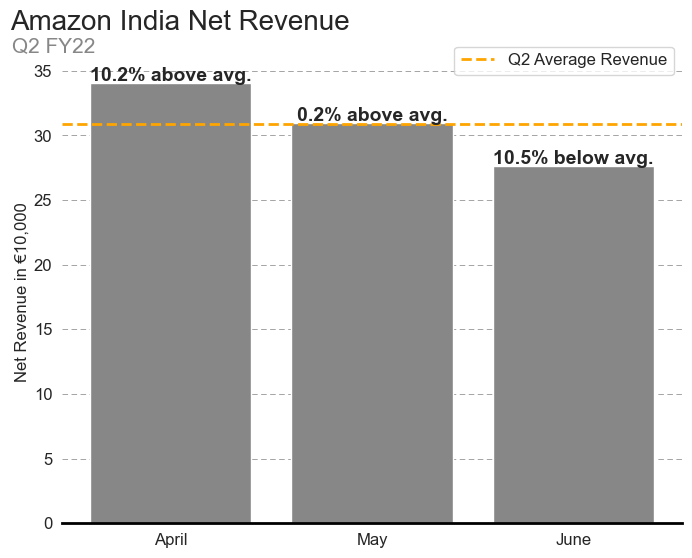

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

# Set-up data
monthly_revenue = df.groupby('month')[['revenue']].sum()

monthly_revenue = monthly_revenue.T[['April','May','June']].T
avg_q2_revenue = monthly_revenue['revenue'].mean()
monthly_revenue['% below avg'] = round((1 - monthly_revenue['revenue'] / avg_q2_revenue) * 100, 1)

# Plot bars
bars = ax.bar(monthly_revenue.index, monthly_revenue['revenue'], color='#878787')

# Add horizontal line for average
ax.axhline(avg_q2_revenue, linestyle='--', color='orange', linewidth=2, label='Q2 Average Revenue')

# Annotate each bar
for bar, pct in zip(bars, monthly_revenue['% below avg']):
    ax.annotate(f"{pct}% below avg." if pct > 0 else f"{abs(pct)}% above avg.",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height() - 7000),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=14, fontweight='bold')

# Titles and labels
ax.set_title("Amazon India Net Revenue", fontsize=20, x=0.19, y=1.05)
ax.text(-0.08, 1.02, "Q2 FY22", fontsize=15, color='#878787', transform=ax.transAxes)
ax.set_ylabel('Net Revenue in €10,000', fontsize=12, labelpad=3)
ax.set_xlabel(None)

# Ticks and grid
ax.set_yticklabels(list(range(0, 41, 5)))
ax.yaxis.grid(linestyle='--', color='gray', linewidth=0.5, dashes=(8, 5))
ax.xaxis.grid(False)
ax.tick_params(axis='both', labelsize=12)

# Spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['bottom'].set_color('black')

plt.legend(bbox_to_anchor=(1,1.05), fontsize=12, fancybox=True)
plt.show()

> **Interpretation prompt:** Revenue [describe trend]. One possible explanation: *[Indian festival calendar? Seasonal fashion? Pricing?]*. To test this, we'd want to check [order count vs. average order value].

# You try it:**

On which days is Amazon earning most of its revenue in India?

1. First create a column containing the day of the week. Hint: use `dt.day_name()` for this (day of the week) or alternatively `dt.day` (day of month).
2. Then, use a groupby and an aggregation function to obtain the total revenue.
3. BONUS: plot the result using `df.plot.bar()` or `df.plot()`

You may want to produce something like this:

<center>
<img src='./images/sketch1.jpg' width='50%'>
</center>

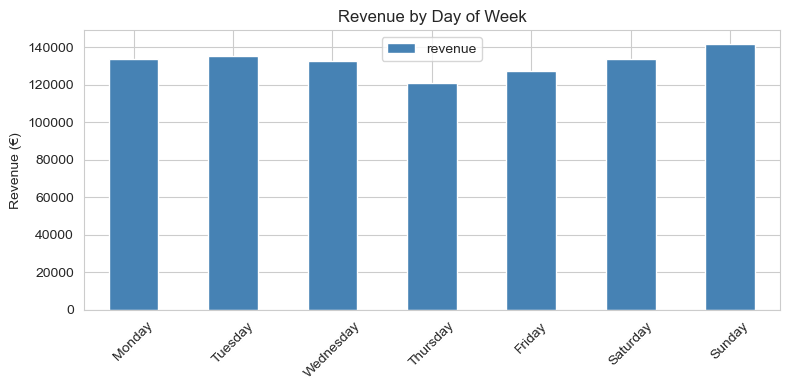

In [166]:
import matplotlib.pyplot as plt

df['day_of_week'] = df['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = df.groupby('day_of_week')[['revenue']].sum().reindex(day_order)

revenue_by_day.plot.bar(figsize=(8, 4), color='steelblue')
plt.title('Revenue by Day of Week')
plt.xlabel('')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Part 3 — Product Portfolio Analysis

### 3.1 Revenue by category

Next question: **Which product categories generate the most revenue?**

Typical question to ask:
* Which category dominates revenue? Do we risk of over-dependence?
* Is there a drop-off after top 3 categories or any other long tail effect?
* Are high-volume categories also high-value? Might lead into later analysis (avg. order value).

We'll use `groupby()` again, but this time by `category`. It works just like with months, but this helps us understand which types of products are performing best.

In [167]:
category_revenue = df.groupby('category')[['revenue']].sum()
category_revenue = category_revenue / category_revenue.sum() * 100

category_revenue = category_revenue.sort_values(ascending=False, by='revenue')
category_revenue

,revenue
category,
Set,49.88
kurta,27.09
Western Dress,14.28
Top,6.81
Ethnic Dress,1.01
Blouse,0.58
Bottom,0.19
Saree,0.16
Dupatta,0.00


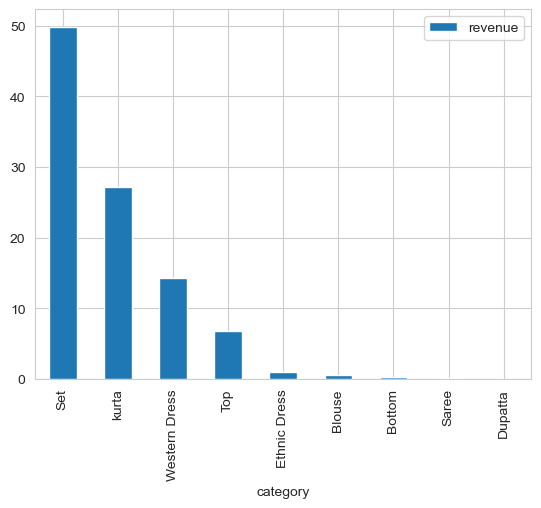

In [168]:
# Basic plot command
category_revenue.plot.bar();

### Analysis: Average Order Value by Category

Revenue alone doesn’t tell the full story. Some categories might generate fewer sales but have *higher order values*.

Let’s calculate **average revenue per order** (AOV) for each product category.

**You try it**

Tabulate and then plot the average order value per category.

You may want to produce something like this:

<center>
<img src='./images/sketch2.jpg' width='50%'>
</center>

In [176]:
category_aov = df.groupby('category')['revenue'].mean()
category_aov = df.groupby('category')['revenue'].mean()
category_aov

category
Blouse           6.30
Bottom           4.35
Dupatta          3.60
Ethnic Dress     8.80
Saree            9.50
Set             10.05
Top              6.31
Western Dress    9.14
kurta            5.48
Name: revenue, dtype: float64

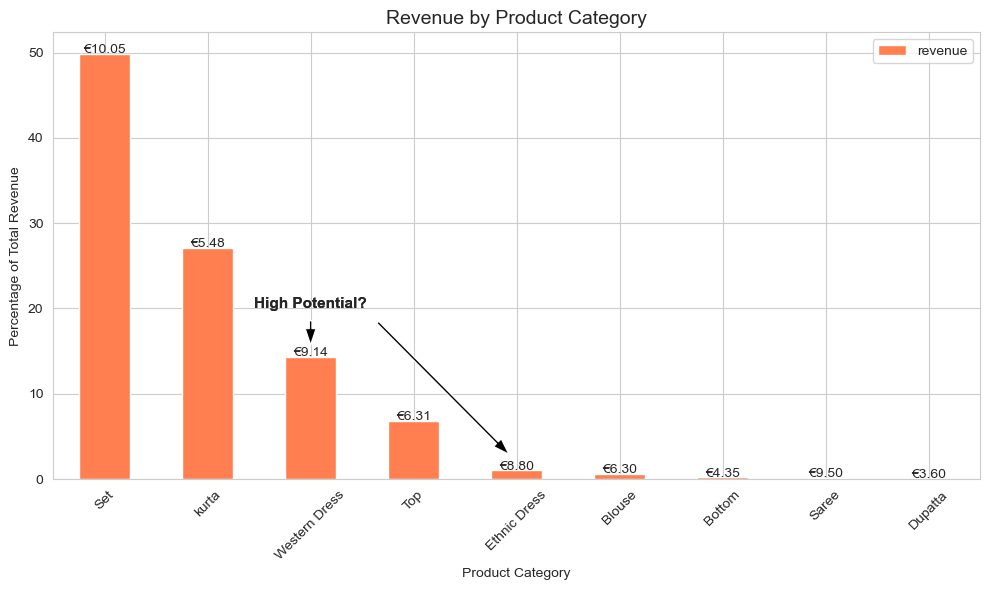

In [175]:
fig, ax = plt.subplots(figsize=(10,6))

bar_colors = ['green' if cat in ['Western Dress', 'Set'] else 'coral' for cat in category_revenue.index]

category_revenue.plot(kind='bar', color='coral', ax=ax)

for i, category in enumerate(category_revenue.index):
    avg_cost = df[df['category'] == category]['revenue'].mean()
    ax.text(i, category_revenue.values[i] +.1, f'€{avg_cost:.2f}', ha='center', fontsize=10)

ax.annotate(
    'High Potential?',
    xy=(2, 15),
    xytext=(2, 15 + 5),
    arrowprops=dict(facecolor='black', shrink=0.15, width=2, headwidth=8),
    ha='center',
    fontsize=11,
    fontweight='bold'
)
ax.annotate(
    'High Potential?',
    xy=(4, 2),
    xytext=(2, 20),
    arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
    ha='center',
    fontsize=11,
    fontweight='bold'
)


plt.title('Revenue by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Percentage of Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis: Product Portfolio Matrix

We can think of each product category as a portfolio element. High revenue = popularity. High AOV = a proxy profitability per sale. The latter is only true here because we're dealing with approximately similar margins. Plotting these gives us a clear 2x2 matrix for strategy.

<center>
<img src='./images/sketch3.jpg' width='50%'>
</center>

This lens can offer some potential strategical actions to take for the product types:
* **Underperformers**: Consider retiring or repositioning
* **Volume Drivers**: Focus on logistics, bundling, efficiency
* **Niche Upside**: Test with promos or better visibility
* **Premium Performers**: Upsell, promote, ...

In [177]:
import matplotlib.pyplot as plt

# Calculate total revenue and AOV per category
category_metrics = df.groupby('category').agg(
    total_revenue   = ('revenue', 'sum'),
    avg_order_value = ('revenue', 'mean')
).reset_index()
category_metrics

,category,total_revenue,avg_order_value
0,Blouse,5406.66,6.30
1,Bottom,1777.58,4.35
2,Dupatta,10.80,3.60
3,Ethnic Dress,9323.69,8.80
4,Saree,1462.40,9.50
5,Set,461950.82,10.05
6,Top,63048.82,6.31
7,Western Dress,132261.97,9.14
8,kurta,250941.30,5.48


### You try it 

Try to scatter plot the total revenue v.s. median order value. The command you'll use is `df.plot.scatter(x=...,y=...)`.

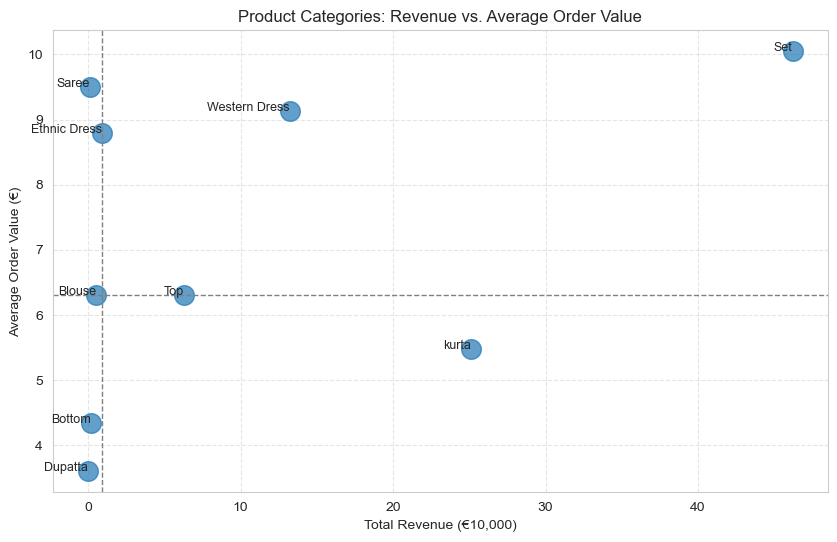

In [178]:
category_metrics = df.groupby('category').agg(
    total_revenue   = ('revenue', 'sum'),
    avg_order_value = ('revenue', 'mean'),
    median_order_value = ('revenue', 'median'),
).reset_index()
category_metrics

### Previous plot
# category_metrics.plot.scatter(
#    x='median_order_value',
#    y='total_revenue',
#    alpha=0.5,
#    color='coral'
# );

#### Fancy scatter plot
category_metrics['revenue_10k'] = category_metrics['total_revenue'] / 10000

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    category_metrics['revenue_10k'],
    category_metrics['avg_order_value'],
    s=200,
    alpha=0.7,
)

# Annotate each point with the category name
for _, row in category_metrics.iterrows():
    ax.text(row['revenue_10k'], row['avg_order_value'], row['category'], fontsize=9, ha='right')

# Add reference lines for median revenue and median AOV
median_revenue = category_metrics['revenue_10k'].median()
median_aov     = category_metrics['avg_order_value'].median()

ax.axhline(median_aov,     color='gray', linestyle='--', linewidth=1)
ax.axvline(median_revenue, color='gray', linestyle='--', linewidth=1)

# Titles and labels
ax.set(
    title='Product Categories: Revenue vs. Average Order Value',
    xlabel='Total Revenue (€10,000)',
    ylabel='Average Order Value (€)'
)
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Cancellations & Returns

Not all orders are good news. In e-commerce, cancellations and returns create serious operational and financial issues:
* Lost revenue: These orders don't convert into sales.
* Shipping and handling costs: Often non-refundable.
* Reverse logistics: Costly and time-consuming.
* Chargebacks: Especially if customers dispute transactions.
* Fraud & abuse: Repeated returns or B2C-to-B2B loopholes.
* Money laundering flags: In some cases, abnormal return behavior is a red flag.

Long story short: cancellations and returns hurt revenue.

Let's measure the size of the problem:

* How many orders were cancelled?
* How many were returned?
* What percentage of total orders does this represent?

So far, you've used `.groupby()` for totals and averages. This time let's introduce `.value_counts()` which is a quick way to count categories in one column, like a faster `.groupby('status').shape`.

*→ This feeds Decision 2: where to focus the operational fix.*

In [ ]:
# Analyse order cancellations — find where the problem is
#
# Step 1: What % of all orders are cancelled?
#   Hint: use df['status'].value_counts() to see all statuses
#   Hint: (df['status'] == 'Cancelled').mean() gives you the rate
#
# Step 2: Does cancellation rate differ by fulfilment type?
#   Hint: df.groupby('fulfilment')['status'].apply(lambda x: (x == 'Cancelled').mean())
#   Store result in: cancel_by_fulfilment
#
# Step 3: Does cancellation rate differ by category?
#   Hint: same pattern, groupby 'category' instead
#   Store result in: cancel_by_category
#
# Step 4: Visualise — which split tells the more actionable story?
#   Hint: try a bar chart on each result

I start by thinking how I will visualize this. I'm usually not a fan of pie charts (hard to cognitively process proportions from angles), but given that we have so many barcharts on the dashboard I think it will add some visual appeal.

Maybe something like this in the Amazon colors?

<center>
  <img src='./images/sketch5.jpg' width='50%'>
</center>

Let's go!

status
Shipped                          75940
Shipped - Delivered to Buyer     28029
Cancelled                        10756
Shipped - Returned to Seller      1949
Shipped - Picked Up                945
Pending                            639
Pending - Waiting for Pick Up      272
Shipped - Returning to Seller      143
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64
=====
Cancelled Orders: 10756 (9.06%)
Returned Orders: 1949 (1.64%)
Total Problematic Orders: 10.70%
=====


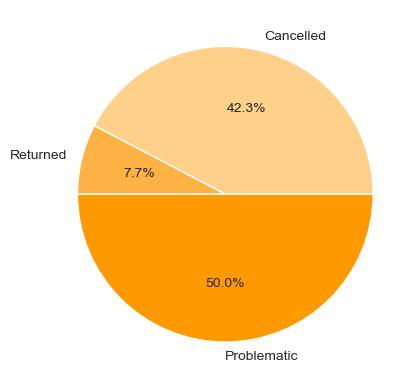

In [179]:
# Step 1: Count all status values
# ---> same as: df.groupby('status').size().sort_values(ascending=False)
print(df['status'].value_counts() )

# Step 2: Filter for problematic orders (cancelled or returned)
cancelled = df[df['status'] == 'Cancelled']
returned  = df[df['status'] == 'Shipped - Returned to Seller']

# Step 3: Calculate totals and percentages
total_orders    = df.shape[0]
cancelled_pct   = cancelled.shape[0] / total_orders * 100
returned_pct    = returned.shape[0] / total_orders * 100
problematic_pct = (cancelled.shape[0]  + returned.shape[0]) / total_orders * 100

print("=====")
print(f"Cancelled Orders: {len(cancelled)} ({cancelled_pct:.2f}%)")
print(f"Returned Orders: {len(returned)} ({returned_pct:.2f}%)")
print(f"Total Problematic Orders: {problematic_pct:.2f}%")


print("=====")
plt.pie(
    [len(cancelled), len(returned), len(cancelled) + len(returned)],
    labels=['Cancelled', 'Returned', 'Problematic'],
    colors=['#FFD08A', '#FFB244', '#FF9900'],
    autopct='%1.1f%%'
)
plt.show()

Observations: High cancellation rates (churn?), high return rates (issues with quality or fit? need to figure this out to avoid expensive logistics).

---
## 🏠 Your Turn — Airbnb Assignment Warm-up

The same pandas skills you just used on Amazon data apply directly to your Airbnb assignment.
Download **`listings.csv`** for your chosen city from [insideairbnb.com](http://insideairbnb.com/get-the-data/) and run the cells below.

> **Madrid example URL** (swap for your city):
> `https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2024-09-13/data/listings.csv.gz`

In [ ]:
# Exercise 1 — Load your Airbnb listings data
# Replace the URL with your city's listings.csv (from insideairbnb.com)
LISTINGS_URL = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2024-09-13/data/listings.csv.gz"

listings = pd.read_csv(LISTINGS_URL, low_memory=False)
print(f"Shape: {listings.shape}")
listings.head(3)

In [ ]:
# Quick sanity: what columns do we have? What's the dtype of 'price'?
print(listings.dtypes[['price', 'neighbourhood_cleansed', 'room_type', 'host_is_superhost']].to_string())
print("\nSample price values:", listings['price'].dropna().head(5).tolist())

In [ ]:
# Exercise 2 — Price is a string like '$1,234.00' — clean it to a float
listings['price_usd'] = (
    listings['price']
    .str.replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Sanity check: median price should be plausible (€50–€300 for most cities)
print(f"Median nightly price: €{listings['price_usd'].median():.0f}")
print(f"Listings with price > €1,000: {(listings['price_usd'] > 1000).sum()} — check these are real or outliers")

In [ ]:
# Exercise 3 — Which neighbourhoods command the highest prices?
# Group by neighbourhood_cleansed, compute median price and listing count
price_by_hood = (
    listings.groupby('neighbourhood_cleansed')
    .agg(
        listing_count = ('id', 'count'),
        median_price  = ('price_usd', 'median'),
        avg_price     = ('price_usd', 'mean')
    )
    .sort_values('median_price', ascending=False)
    .round(0)
)

# Sanity: listing_count should sum to the number of rows with a valid neighbourhood
print(f"Total listings accounted for: {price_by_hood['listing_count'].sum()}  (expect ~{len(listings)})")
price_by_hood.head(10)

In [ ]:
# Exercise 4 — Does room type explain price differences?
price_by_type = (
    listings.groupby('room_type')
    .agg(
        listing_count = ('id', 'count'),
        median_price  = ('price_usd', 'median')
    )
    .sort_values('median_price', ascending=False)
)
price_by_type

In [ ]:
# Exercise 5 — Superhost premium: do superhosts charge more?
# host_is_superhost is 't' (true) or 'f' (false)
superhost_premium = (
    listings.groupby('host_is_superhost')['price_usd']
    .median()
    .rename(index={'t': 'Superhost', 'f': 'Regular host'})
)
print(superhost_premium)

premium_pct = (superhost_premium['Superhost'] / superhost_premium['Regular host'] - 1) * 100
print(f"\nSuperhost premium: {premium_pct:+.1f}%")
print("\n💡 AI prompt: 'Given this superhost pricing table, what business recommendations would you make to a new host trying to maximise revenue?'")

In [ ]:
# Exercise 6 — Quick visualisation: top 10 neighbourhoods by median price
import matplotlib.pyplot as plt

top10 = price_by_hood.head(10)['median_price']

fig, ax = plt.subplots(figsize=(9, 4))
top10.sort_values().plot.barh(ax=ax, color='#0891B2')
ax.set_xlabel('Median nightly price (€)')
ax.set_title('Top 10 neighbourhoods by median price')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 🔍 Sanity: does the ranking match your intuition about the city?

> **Reflection for your memo:**
> - Which 2–3 neighbourhoods stand out as high-price, high-volume zones?
> - Is the superhost premium consistent across room types, or only for entire homes?
> - What's one hypothesis this data raises that you'd want to test further?

### 3.3 Build your recommendation

Based on your analysis, fill in this template:

---

**Decision 1 — Strategic (which category to invest in):**

We recommend doubling down on **[category]** because it has [revenue share]% of revenue, an average order value of €[X], and order volume of [N]. The risk of over-dependence on one category is [low/medium/high] because [reason].

**Decision 2 — Operational (reduce cancellation rate):**

Cancellation rate is highest in **[category/fulfilment type/size]** at [X]%. The most actionable fix is [specific action], which should reduce cancellations by targeting [root cause].

---

> 🤖 **AI tip for presentation:** Once your DataFrames are 100% correct, ask Claude: *"Here is a summary table [paste]. Write me a 3-sentence executive summary of the key finding and recommendation."* — but always verify that the AI-written summary accurately reflects YOUR numbers.

---
## BONUS — Merging Datasets & Pivot Tables

If you have time, explore these more advanced pandas features.

In [ ]:
# Bonus: Weekly revenue trend (using resample on a datetime index)
df_indexed = df.set_index('date').sort_index()
weekly_revenue = df_indexed['revenue'].resample('W').sum()

weekly_revenue.plot(figsize=(10, 4), color='#0891B2', linewidth=2,
                    title='Weekly Revenue Trend — Q2 2022',
                    ylabel='Revenue (EUR)')
plt.tight_layout()
plt.show()

In [ ]:
# Bonus: Pivot table — cancellation rate by category × month
df['month_num'] = df['date'].dt.month

pivot = df.pivot_table(
    index='category',
    columns='month',
    values='is_cancelled',
    aggfunc='mean'
)[month_order]

(pivot * 100).round(1)

---
## Solutions

<details>
<summary>Click to reveal: Day-of-week revenue</summary>

```python
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_revenue = df.groupby('day_of_week')[['revenue']].sum().loc[day_order]
daily_revenue.plot.bar(figsize=(9,4), color='#0891B2', legend=False,
                       title='Revenue by Day of Week', ylabel='EUR')
```
</details>

<details>
<summary>Click to reveal: Cancellation by fulfilment</summary>

```python
cancel_by_fulfilment = (
    df.groupby('fulfilment')
    .agg(total=('order_id','count'), cancelled=('is_cancelled','sum'))
    .assign(rate=lambda x: (x['cancelled']/x['total']*100).round(1))
)
```
</details>